# 4교시 실습 — 그림으로 인사이트 뽑기 📊

> **사용법**
> - 🔵 **수업** = 강사와 함께 실행 · 🟡 **셀프** = 집에서 직접 채울 셀(빈칸 `____`)
> - 이 파일은 **연습용(`_blank`)** 입니다. 막히면 정답본(`_solution`)과 대조하세요.
> - 정답본에는 **실행 결과(그래프) + 💡해석**이 셀마다 달려 있습니다.

---

## 🎨 오늘의 상황

지난 시간(3교시)에 여러분은 지저분한 데이터를 깨끗이 정제했습니다.
오늘 아침, 팀장님이 그 결과 표를 한참 보더니 한숨을 쉽니다.

> *"숫자가 빼곡한 표만 보면 회의 때 다들 졸아…*
> *이걸 **그림 한 장**으로 바꿔줄 수 있어? 보는 순간 '아!' 하고 와닿게."*

분석에서 **시각화(visualization)** 는 장식이 아닙니다.
**사람의 눈은 표보다 그림에서 패턴을 100배 빨리 찾습니다.** 오늘 그 무기를 배웁니다.

오늘 그릴 4대 차트:

| 차트 | 한 줄 정의 | 언제 쓰나 |
|---|---|---|
| **산점도** scatter | 두 숫자의 **관계** | "키가 크면 몸무게도?" |
| **히스토그램** hist | 한 숫자의 **분포** | "성적이 어디에 몰렸나?" |
| **박스플롯** box | 그룹별 분포 **비교** | "반별 점수 차이는?" |
| **막대그래프** bar | 그룹 **크기 비교** | "어느 나라가 1등?" |

데이터는 🐧펭귄 · 🌍세계행복(2025) · 🍽️식당팁 — 세 가지를 오갑니다.

## 🎯 학습 목표 — 이 실습을 끝내면

- **4대 차트**(산점도·히스토그램·박스플롯·막대)를 그릴 수 있다
- 무엇을 보고 싶은지에 따라 **알맞은 차트를 고를** 수 있다
- **심슨의 역설**처럼 '나눠 보면 뒤집히는' 경우를 시각화로 잡아낼 수 있다
- 차트에서 **패턴·이상치·관계를 읽어낼** 수 있다
- **'메시지가 있는 차트'** 로 결과를 전달할 수 있다

## Part 0. 준비 — 도구 + 한글 폰트 + 데이터  🔵

아래 셀은 (1) 그리기 도구 `seaborn`/`matplotlib`을 불러오고, (2) 그래프에 한글이 깨지지 않게 폰트를 설정하고, (3) 펭귄·팁 데이터를 불러옵니다.
**폰트를 못 찾아도 에러 없이** 넘어가도록 안전장치(try/except)를 넣었습니다 — 영문 라벨 차트는 항상 정상입니다.

In [1]:
# === 데이터 로드 설정 (로컬/코랩 자동) ===
import os, urllib.request   # 파일 존재 확인 + 인터넷 다운로드 도구
DATA_BASE = "https://raw.githubusercontent.com/acho98/gunyang-data/main/"   # 데이터가 올라간 깃허브 주소
def data_path(fname):
    """로컬에 있으면 로컬, 없으면 깃허브에서 바로 로드 (코랩 OK)."""
    for _p in ("../data/" + fname, "data/" + fname):   # 내 컴퓨터의 두 후보 경로를 차례로 확인
        if os.path.exists(_p):   # 파일이 실제로 있으면
            return _p   # 그 로컬 경로를 사용
    return DATA_BASE + fname   # 없으면 깃허브 주소로 대체(코랩에서도 동작)

import pandas as pd   # 표(데이터프레임) 다루는 도구
import seaborn as sns   # 한 줄로 예쁜 차트를 그리는 도구
import matplotlib.pyplot as plt   # 차트 제목/축 등 세부 조정 도구
from matplotlib import font_manager as fm   # 한글 폰트를 등록하는 도구

# --- 한글 폰트 설정: 실패해도 경고만 내고 넘어감(차트는 영문으로 정상 출력) ---
def set_korean_font():
    _cands = ["../data/BMDOHYEON.ttf", "data/BMDOHYEON.ttf", "BMDOHYEON.ttf"]   # 한글 폰트 파일 후보 경로들
    if not any(os.path.exists(p) for p in _cands):   # 어디에도 폰트가 없으면
        try:
            urllib.request.urlretrieve(DATA_BASE + "BMDOHYEON.ttf", "BMDOHYEON.ttf")   # 깃허브에서 폰트 내려받기
        except Exception:   # 다운로드 실패해도
            pass   # 그냥 넘어감(에러로 멈추지 않게)
    for path in _cands:   # 후보 경로를 하나씩 확인하며
        if os.path.exists(path):   # 폰트 파일이 있으면
            try:
                fm.fontManager.addfont(path)   # 그 폰트를 matplotlib에 등록
                plt.rcParams["font.family"] = fm.FontProperties(fname=path).get_name()   # 기본 글꼴을 한글 폰트로 지정
                plt.rcParams["axes.unicode_minus"] = False   # 마이너스(−) 기호가 깨지지 않게
                return   # 성공했으니 함수 종료
            except Exception:   # 등록 실패해도
                pass   # 다음 후보로 넘어감
    print("(안내) 한글 폰트를 못 찾았어요. 영문 라벨 차트는 정상입니다.")   # 끝까지 못 찾았을 때 안내
set_korean_font()   # 위에서 정의한 폰트 설정 함수 실행

penguins = sns.load_dataset("penguins")   # 펭귄 측정 데이터 344마리
tips = sns.load_dataset("tips")           # 식당 팁 데이터 244건
print("준비 완료! 펭귄", penguins.shape, "/ 팁", tips.shape)   # 잘 불러왔는지 행/열 개수 출력

준비 완료! 펭귄 (344, 7) / 팁 (244, 7)


💡 **해석**: 에러 없이 `준비 완료!` 가 찍히면 성공. 앞으로 거의 모든 차트는 **`sns.차트(data=표, x=..., y=...)` + `plt.show()`** 단 두 줄 패턴입니다. 외울 건 차트 이름뿐이에요.

## Part 1. 왜 그림인가 — 표 vs 그림  🔵

말로 백 번 설명하는 것보다 한 번 보는 게 빠릅니다.
먼저 펭귄 날개 길이를 **표(숫자)** 로 보고, 바로 **그림** 으로 봅니다. 어느 쪽이 패턴이 잘 보이나요?

In [2]:
# 표로 보기: 날개 길이 앞 20개 숫자
# flipper_length_mm: 펭귄 지느러미 길이
print(penguins["flipper_length_mm"].dropna().head(20).tolist())   # 결측치 빼고 앞 20개를 리스트로 출력

[181.0, 186.0, 195.0, 193.0, 190.0, 181.0, 195.0, 193.0, 190.0, 186.0, 180.0, 182.0, 191.0, 198.0, 185.0, 195.0, 197.0, 184.0, 194.0, 174.0]


💡 **해석**: 숫자 `181, 186, 195, ...` 가 죽 나열됩니다. 이걸 눈으로 훑어서 *"값이 어디에 몰려 있는지"* 알아채긴 거의 불가능하죠. 사람 눈은 숫자 나열에 약합니다.

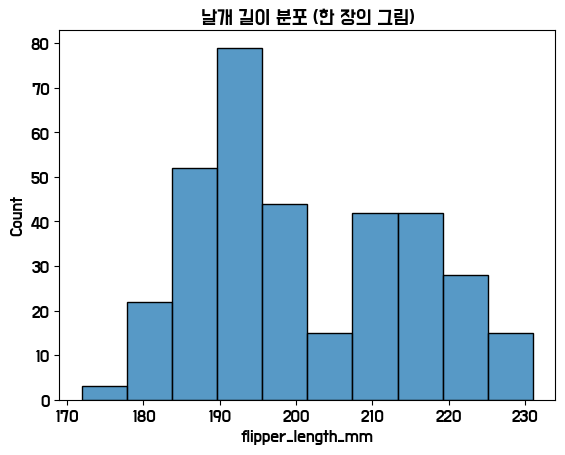

In [3]:
# 같은 데이터를 그림으로 보기
sns.histplot(data=penguins, x="flipper_length_mm")   # 히스토그램: 날개 길이가 어디에 몰렸나(분포)
plt.title("날개 길이 분포 (한 장의 그림)")   # 그래프 제목
plt.show()   # 완성된 그림을 화면에 표시

💡 **해석**: 똑같은 데이터인데 그림으로 보니 **봉우리가 두 개**(약 190mm, 215mm 부근)인 게 단번에 보입니다. "펭귄 중에 작은 무리·큰 무리가 따로 있나?" 라는 질문이 저절로 떠오르죠. **이게 시각화의 힘** — 표는 답을 숨기고, 그림은 질문을 줍니다.

## Part 2. 산점도(scatter) — 두 변수의 *관계*  🔵

산점도는 점 하나가 **개체 하나**(펭귄 한 마리)입니다.
가로축·세로축에 숫자 변수를 하나씩 놓으면, 두 변수가 **같이 커지는지/반대인지** 보입니다.

펭귄의 **부리 길이(x)** 와 **부리 깊이(y)** 관계를 봅시다. 부리가 길면 깊이도 깊을까요?

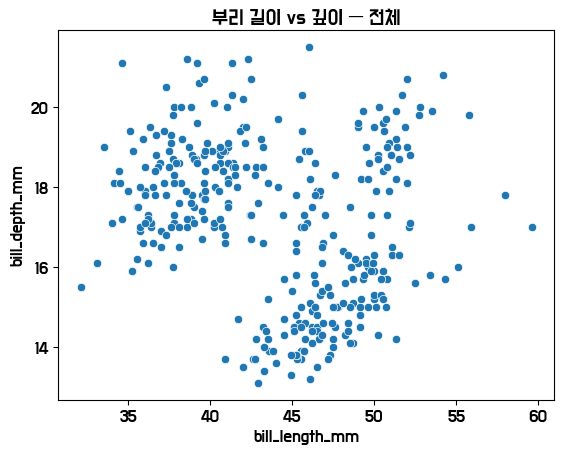

전체 상관계수: -0.235


In [4]:
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")   # 산점도: 점 하나가 펭귄 한 마리(길이↔깊이 관계)
plt.title("부리 길이 vs 깊이 — 전체")   # 그래프 제목
plt.show()   # 그림 표시
print("전체 상관계수:", round(penguins["bill_length_mm"].corr(penguins["bill_depth_mm"]), 3))   # 두 변수 상관계수(부호로 방향 확인)

💡 **해석**: 점들이 전체적으로 **오른쪽 아래로** 흐릅니다. 상관계수도 **−0.235** (음수) → *"부리가 길수록 오히려 얕다?"* 이상한 결론이 나옵니다.
(즉, 부리가 길수록 깊이가 약간 작아지는 경향이 있는 것처럼 보인다.)

생물학적으로 말이 안 되죠. 뭔가 함정이 있습니다. **다음 셀에서 색을 나눠** 봅시다.

### 같은 그림에 *색*만 나눠보면 — 1교시 심슨 역설!  🔵

이번엔 **종(species)별로 색**(`hue`)을 입혀 똑같이 그립니다. 점은 그대로인데 색만 추가됩니다.

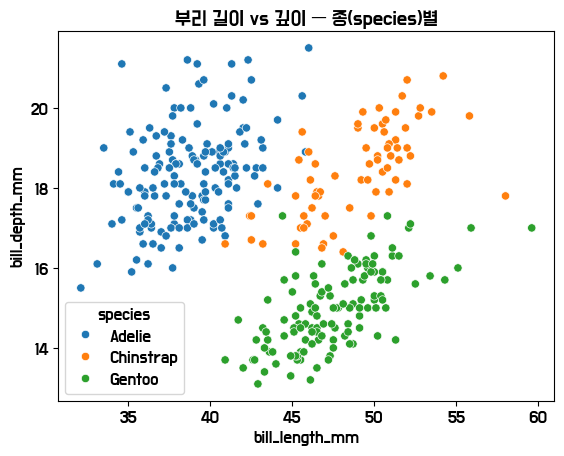

    Adelie 상관: +0.391
 Chinstrap 상관: +0.654
    Gentoo 상관: +0.643


In [5]:
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species")   # hue=종별로 점 색을 다르게(그룹 구분)
plt.title("부리 길이 vs 깊이 — 종(species)별")   # 그래프 제목
plt.show()   # 그림 표시
for sp in ["Adelie", "Chinstrap", "Gentoo"]:   # 종 세 개를 하나씩 반복
    sub = penguins[penguins["species"] == sp]   # 그 종에 해당하는 행만 골라내기
    print(f"{sp:>10} 상관: {sub['bill_length_mm'].corr(sub['bill_depth_mm']):+.3f}")   # 종별 상관계수(+/- 부호까지 출력)

💡 **해석**: 반전입니다! **종별로 나눠 보면 각 색 덩어리 안에서는 점들이 오른쪽 *위*로** 올라갑니다(예: Gentoo 상관 **+0.643**, 양수). 즉 *"같은 종 안에서는 부리가 길수록 깊이도 깊다"* — 상식과 맞죠.

전체로 뭉치면 음(−), 그룹으로 나누면 양(+). **이게 바로 1교시의 심슨 역설(UC버클리)!** 종마다 부리 비율이 달라서, 안 나누고 합치면 방향이 뒤집힌 겁니다.
👉 교훈: **"전체 평균"만 보지 말고 의미 있는 그룹으로 나눠 보라.** 산점도의 색(`hue`) 한 줄이 함정을 잡아냅니다.

## Part 3. 히스토그램(histogram) — 한 변수의 *분포*  🟡

히스토그램은 값의 범위를 막대 구간으로 쪼개 **"각 구간에 몇 개 있나"** 를 셉니다.
한 변수가 **어디에 몰려 있고, 치우쳤는지** 볼 때 씁니다.

펭귄 **몸무게(`body_mass_g`)** 의 분포를 직접 그려보세요.
> 💡 힌트: `sns.histplot(data=penguins, x="body_mass_g")`

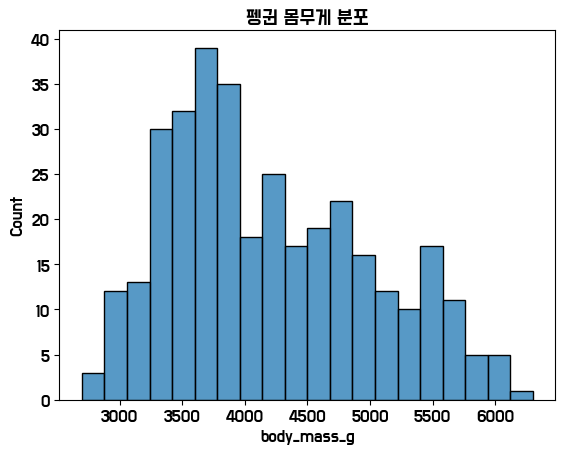

In [6]:
sns.histplot(data=penguins, x="body_mass_g", bins=20)   # 히스토그램: 몸무게 분포, bins=20은 막대 구간을 20칸으로
plt.title("펭귄 몸무게 분포")   # 그래프 제목
plt.show()   # 그림 표시

💡 **해석**: 대부분 **3000~4500g** 에 몰려 있고, 5000g을 넘는 무거운 무리가 오른쪽에 따로 보입니다(=Gentoo 종). 분포가 오른쪽으로 살짝 꼬리를 끄는 모양이에요. 평균(약 4200g) 하나로는 이 "두 무리"가 안 보이죠 — **분포를 그려야 보입니다.**

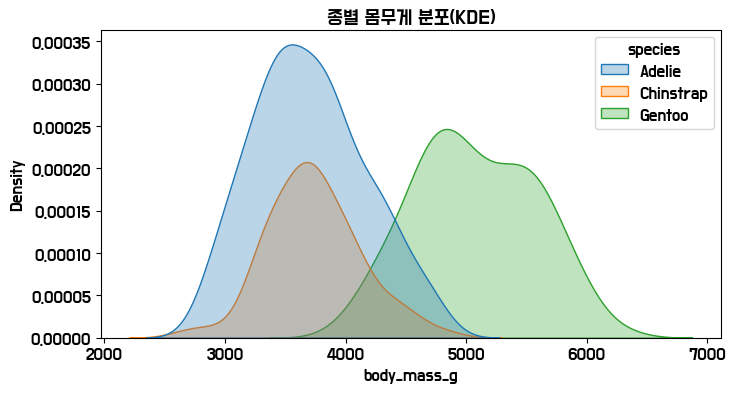

In [9]:
plt.figure(figsize=(8,4))

sns.kdeplot(
    data=penguins,
    x="body_mass_g",
    hue="species",
    fill=True,
    alpha=0.3
)

plt.title("종별 몸무게 분포(KDE)")
plt.show()

아까는 평균 4200g만 봤는데, 실제로는 종에 따라 몸무게 분포가 다릅니다. 특히 Gentoo는 다른 종보다 훨씬 무겁습니다.

## Part 4. 박스플롯(box) — 그룹별 분포 *비교*  🟡

박스플롯은 그룹마다 **중앙값(가운데 선)·중간 50%(상자)·범위(수염)·이상치(점)** 를 한 번에 보여줍니다.
"그룹끼리 분포가 어떻게 다른가"를 비교할 때 최강입니다.

펭귄 **종(species)별 몸무게(`body_mass_g`)** 분포를 박스플롯으로 비교하세요.
> 💡 힌트: `sns.boxplot(data=penguins, x="species", y="body_mass_g")`

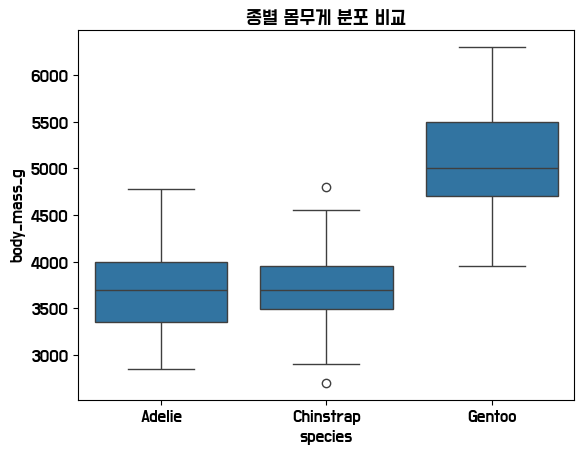

In [12]:
sns.boxplot(data=penguins, x="species", y="body_mass_g")   # 박스플롯: 종별(x) 몸무게(y) 분포를 나란히 비교
plt.title("종별 몸무게 분포 비교")   # 그래프 제목
plt.show()   # 그림 표시

💡 **해석**: **Gentoo의 상자가 확 위에** 있습니다(중앙값 약 5000g). Adelie·Chinstrap은 비슷하게 아래쪽(약 3700g). Part 3 히스토그램에서 봤던 "두 무리"의 정체가 여기서 밝혀집니다 — **무거운 무리 = Gentoo**! 박스플롯 한 장이 "누가 더 무거운가"를 끝냅니다.

## Part 5. 막대그래프(bar) — 그룹 *크기 비교*  🔵

막대그래프는 **누가 더 큰가/많은가**를 비교할 때 가장 직관적입니다.
2025년 **가장 행복한 나라 Top 10** 을 막대로 비교합니다.

In [14]:
happy = pd.read_csv(data_path("world_happiness_owid.csv"))   # 세계 행복 보고서 CSV 불러오기
happy_2025 = happy[happy["year"] == 2025].dropna(subset=["cantril_ladder_score"])   # 2025년 + 점수 있는 행만 추리기
print("2025년 데이터 국가 수:", len(happy_2025))   # 남은 국가 수 출력

2025년 데이터 국가 수: 158


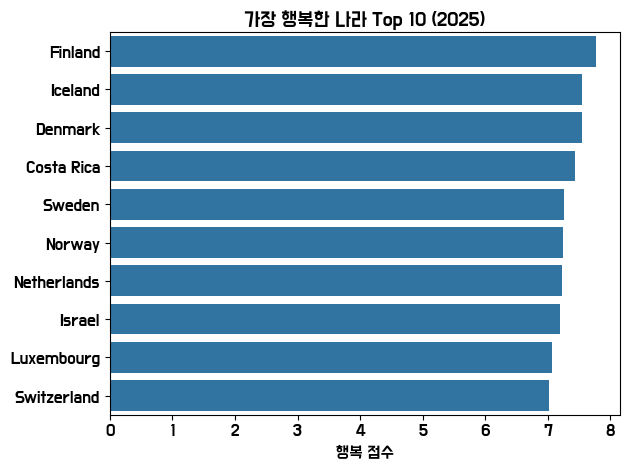

In [16]:
top10 = happy_2025.sort_values("cantril_ladder_score", ascending=False).head(10)   # 점수 내림차순 정렬 후 상위 10개국
sns.barplot(data=top10, x="cantril_ladder_score", y="entity")   # 가로 막대: 나라(y)별 점수(x) 크기 비교
plt.title("가장 행복한 나라 Top 10 (2025)")   # 그래프 제목
plt.xlabel("행복 점수"); plt.ylabel("")   # x축 이름 지정 + y축 이름은 비움
plt.tight_layout(); plt.show()   # 라벨 안 잘리게 여백 정리 후 그림 표시

💡 **해석**: **핀란드가 1위(7.76)**, 이어 아이슬란드·덴마크·코스타리카·스웨덴… 북유럽이 상위권을 휩쓸었습니다. 가로 막대(`y`에 나라 이름)는 이름이 길어도 안 겹쳐서 **순위 비교에 딱**입니다. 1교시에서 배운 "비교는 막대"가 그대로죠.

### 직접 그려보기 — 요일별 매출  🟡

식당 데이터(`tips`)에서 **요일(`day`)별 평균 결제금액(`total_bill`)** 을 막대그래프로 그려보세요.
주말 장사가 평일보다 정말 잘 될까요?
> 💡 힌트: `sns.barplot(data=tips, x="day", y="total_bill")`

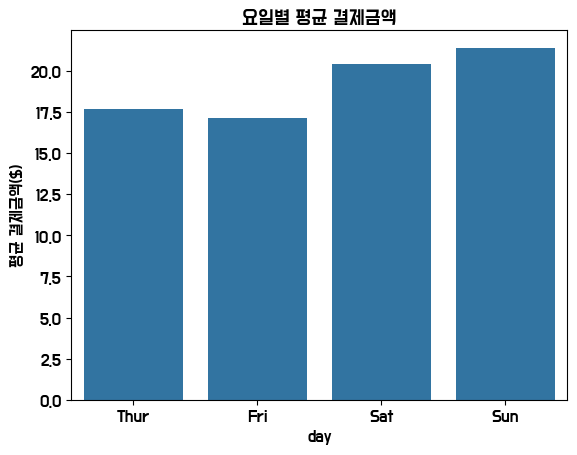

In [18]:
sns.barplot(data=tips, x="day", y="total_bill", errorbar=None)  # 막대: 요일(x)별 평균 결제금액(y) 자동 계산해 비교
plt.title("요일별 평균 결제금액")   # 그래프 제목
plt.ylabel("평균 결제금액($)")   # y축 이름(단위 표시)
plt.show()   # 그림 표시

💡 해석  
주말(토 20.4, 일 21.4)이 평일(목 17.7, 금 17.2)보다 결제금액이 큽니다.
따라서 이 데이터에서는 주말 고객이 평일 고객보다 더 많은 금액을 지출하는 경향이 있습니다.
다만 이것만 보고 "주말이라서 더 쓴다" 라고 단정할 수는 없습니다.

💡 왜 단정할 수 없을까?  
주말에는 가족 단위 방문이 많을 수 있음  
주말에는 모임·회식이 많을 수 있음  
주말에는 고가 메뉴 주문 비율이 높을 수 있음  
주말에는 손님 구성 자체가 다를 수 있음  

요일 ↔ 결제금액 상관관계는 보이지만 주말 → 결제금액 증가 인과관계는 아직 모릅니다.

## Part 6. 한 걸음 더 — 선그래프(line)로 *시간 흐름* 보기  🔵

시간에 따라 변하는 데이터(주가·기온·환율…)는 **선그래프**가 제격입니다.
강사의 현장 데이터 — **금(Gold) 5년 시세** 를 선으로 그려봅니다.

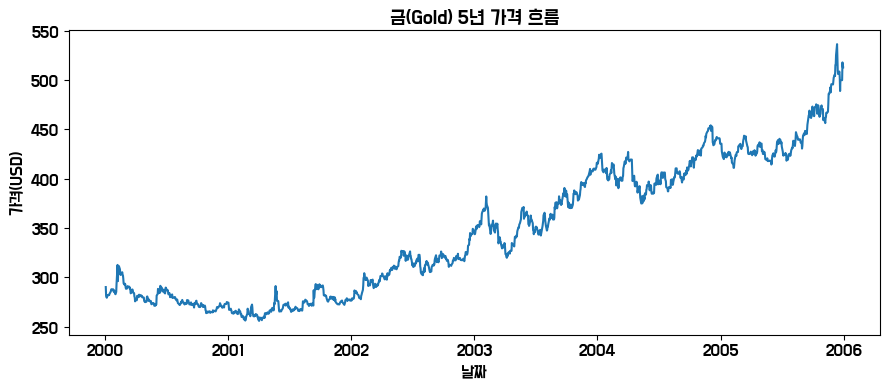

In [19]:
gold = pd.read_csv(data_path("gold_5y.csv"))   # 금 5년 시세 CSV 불러오기
gold["ds"] = pd.to_datetime(gold["ds"])   # 날짜 글자(ds)를 진짜 날짜 자료형으로 변환
plt.figure(figsize=(9, 4))   # 그림 크기를 가로 9 세로 4로 지정
plt.plot(gold["ds"], gold["y"])   # 선그래프: 날짜(x)에 따른 가격(y) 흐름
plt.title("금(Gold) 5년 가격 흐름")   # 그래프 제목
plt.xlabel("날짜"); plt.ylabel("가격(USD)")   # x축·y축 이름
plt.tight_layout(); plt.show()   # 여백 정리 후 그림 표시

💡 **해석**: 점이 아니라 **선으로 이으면 '흐름(추세)'** 이 보입니다. 오르내림 속에서도 장기적으로 우상향하는 구간, 급락하는 구간이 한눈에. 산점도(관계)·히스토그램(분포)·막대(비교)와 달리, **선그래프는 '시간 순서'가 핵심**일 때 씁니다.

## Part 7. 종합 미니 도전 — 차트 골라 쓰기  🟡

지금까지 4+1 종류를 배웠습니다. 이제 **"질문에 맞는 차트를 직접 고르는"** 연습입니다.

**질문**: *"식당에서 점심(Lunch)과 저녁(Dinner) 중 언제 결제금액이 더 클까?"*
→ "그룹별 분포 비교"이므로 **박스플롯**이 적절합니다. `x="time"`, `y="total_bill"` 로 그려보세요.
> 💡 힌트: `sns.boxplot(data=tips, x="time", y="total_bill")`

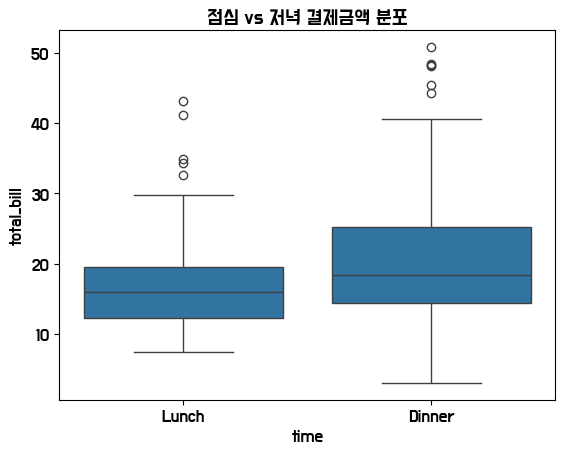

In [20]:
sns.boxplot(data=tips, x="time", y="total_bill")   # 박스플롯: 점심/저녁(x)별 결제금액(y) 분포 비교
plt.title("점심 vs 저녁 결제금액 분포")   # 그래프 제목
plt.show()   # 그림 표시

💡 **해석**: **저녁(Dinner) 상자가 점심(Lunch)보다 위**에 있습니다 — 저녁에 더 많이 씁니다(저녁 손님이 술·디저트까지?). 게다가 저녁은 상자가 길고 위쪽 이상치(점)도 많죠 → "가끔 아주 큰 결제"가 저녁에 발생. 평균 막대 하나보다 **박스플롯이 '퍼짐'까지** 알려줍니다.

### 마지막 도전 — 색으로 한 겹 더  🟡

박스플롯에 `hue="smoker"` 를 추가해, **흡연석/금연석**까지 나눠 비교해보세요.
하나의 그림에 "시간대 × 흡연여부"를 동시에 담는 겁니다.
> 💡 힌트: `sns.boxplot(data=tips, x="time", y="total_bill", hue="smoker")`

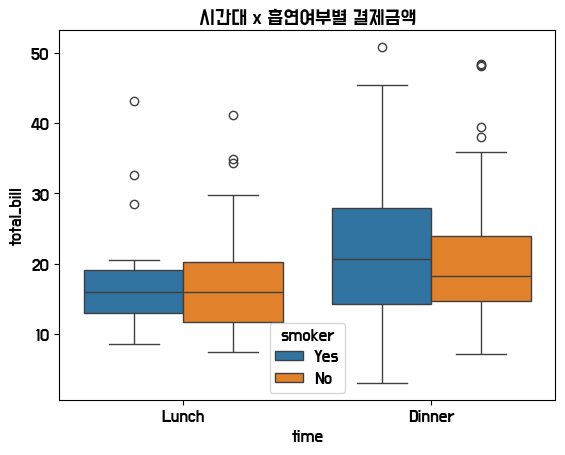

In [21]:
sns.boxplot(data=tips, x="time", y="total_bill", hue="smoker")   # hue=흡연여부로 상자를 한 겹 더 나눠 동시 비교
plt.title("시간대 x 흡연여부별 결제금액")   # 그래프 제목
plt.show()   # 그림 표시

💡 **해석**: `hue` 한 줄로 상자가 둘씩 짝지어 나뉘었습니다. 시간대(점심/저녁)와 흡연여부를 **동시에** 비교할 수 있죠. 이렇게 변수를 한 겹씩 더 얹으며 "누가·언제·어떤 그룹"을 파고드는 게 분석가의 실력입니다. (단, 너무 많이 얹으면 오히려 안 보임 — **한 그림엔 메시지 하나**가 원칙!)

저녁 시간대에는 흡연자 그룹의 결제금액 중앙값이 약간 높게 보입니다. 다만 분포가 상당 부분 겹치므로 흡연 여부가 결제금액의 원인이라고 결론 내릴 수는 없습니다. 실제로는 인원수(size)나 테이블 구성 같은 다른 변수의 영향일 수 있습니다.

## Part 8. 어떤 차트로 봐야 할까? — 차트 선택 가이드  🔵

> 💬 **잠깐 — 오늘 배운 `sns.histplot`, `boxplot` 같은 코드는 외우지 않아도 됩니다.**
> 까먹으면 검색하거나 AI에게 물으면 1초면 나와요. **진짜 실력은 "이 질문엔 어떤 차트가 맞지?"를 고르고, 결과를 읽어내는 것** — 그건 사람의 몫입니다.

차트는 멋으로 고르는 게 아니라 **"내가 답하고 싶은 질문"** 에 맞춰 고릅니다.

| 내가 답하고 싶은 질문 | 알맞은 차트 | 오늘 그린 예 |
|---|---|---|
| "값이 어디에 몰려 있나?" (변수 1개) | **히스토그램** | 펭귄 몸무게·세계 행복 점수 |
| "두 숫자가 같이 움직이나?" (관계) | **산점도** | 부리 길이 ↔ 깊이 |
| "그룹끼리 분포가 어떻게 다른가?" | **박스플롯** | 종별 몸무게·점심 vs 저녁 |
| "누가 더 큰가/많은가?" (순위·비교) | **막대그래프** | 가장 행복한 나라 Top10 |
| "시간에 따라 어떻게 변하나?" | **선그래프** | 금 시세 흐름 |

**차트 고르는 3단계 사고**
1. **무슨 질문인가?** — 분포? 관계? 비교? 추세?
2. **변수 종류는?** — 범주형(종류)인가 수치형(숫자)인가, 몇 개인가?
3. 그 둘에 **맞는 차트**를 고른다. (위 표가 곧 지도)

**초보가 자주 하는 실수 (피하세요)**
- ❌ 막대그래프 y축을 0이 아닌 데서 시작 → 차이가 과장돼 보임 (눈속임!)
- ❌ 파이차트에 조각 10개 → 비교 불가. (파이는 3~4조각까지만)
- ❌ 한 그림에 색(`hue`)·선·점 너무 많이 → **한 그림엔 메시지 하나**
- ❌ 제목·축 이름·단위 빠뜨리기 → 남이 못 알아봄
- ✅ 색은 '예쁘라고'가 아니라 **의미가 있을 때만** (그룹 구분 등)

## Part 9. 그림을 '읽는' 법 — 결과 해석 예시 5가지  🔵

차트를 그리는 건 시작일 뿐. **진짜 일은 "그래서 이게 무슨 뜻인가"를 읽는 것**입니다.
같은 그림을 봐도 초보와 분석가는 다르게 읽어요. 아래 5가지 예시로 그 차이를 느껴보세요.

> 🧠 **결과 해석 5문 체크리스트** (어떤 그림이든 이걸 던지세요)
> ① 분포부터 봤나? (평균 하나만 믿지 않았나) ② 평균의 함정은 없나? ③ 그룹으로 나눠보면 다른가?
> ④ 상관을 인과로 착각하지 않았나? ⑤ 이 데이터(표본)로 일반화해도 되나?

### 사례 ① 히스토그램에 봉우리가 두 개  📊
*(예: 펭귄 날개 길이·몸무게 분포)*

- 🟥 **초보의 해석**: "평균이 약 4,200g이네. 펭귄은 보통 4,200g이구나."
- ✅ **분석가의 해석**: "봉우리가 **두 개**다. 평균 4,200g인 펭귄은 사실 별로 없고, **작은 무리(~3,700g)와 큰 무리(~5,000g)가 섞인 것**. 평균 하나로 뭉뚱그리면 진실을 놓친다. → '무엇이 두 무리를 가르지?'(종?) 질문이 생긴다."
- 💡 **교훈**: 분포를 보면 **평균이 숨긴 '여러 무리'**가 보인다. (1교시 *평균의 함정*)

### 사례 ② 산점도 — 전체로 보면 음(−), 색으로 나누면 양(+)  🔀
*(예: 펭귄 부리 길이 ↔ 깊이)*

- 🟥 **초보의 해석**: "전체 상관이 −0.23이니까, 부리가 길수록 얕다."
- ✅ **분석가의 해석**: "종별로 **색(`hue`)**을 나눴더니 각 무리 안에선 오히려 **양(+)의 관계**다. 전체로 합치면 방향이 뒤집힌 것 = **심슨의 역설**. → '나눠 보면 다를까?'를 안 던졌으면 정반대 결론을 낼 뻔했다."
- 💡 **교훈**: **전체 평균을 의심하고 의미 있는 그룹으로 쪼개라.** (1교시 *심슨의 역설*)

### 사례 ③ 막대그래프 순위 — 1등만 보지 마라  📊
*(예: 가장 행복한 나라 Top10)*

- 🟥 **초보의 해석**: "1등은 핀란드네. 끝."
- ✅ **분석가의 해석**: "(1) 상위권이 **북유럽에 몰려 있다** → 우연이 아니라 패턴(복지·신뢰?). (2) 1등과 10등의 **격차**는 의외로 작다. (3) 막대 y축(또는 x축)이 **0부터 시작하는지** 확인 — 안 그러면 차이가 과장돼 보인다. (4) **빠진 나라**(한국은?)도 본다."
- 💡 **교훈**: 순위표는 **1등이 아니라 '격차·패턴·축·빠진 것'**을 읽는다.

### 사례 ④ 박스플롯 — 가운데 선만 보지 마라  📦
*(예: 점심 vs 저녁 결제금액)*

- 🟥 **초보의 해석**: "저녁 중앙값이 더 높네. 저녁이 더 많이 쓴다."
- ✅ **분석가의 해석**: "중앙값뿐 아니라 **상자 길이(퍼짐)**와 **위쪽 점(이상치)**도 본다. 저녁은 중앙값도 높지만 **퍼짐이 크고 큰 결제(이상치)가 많다** → '저녁엔 가끔 아주 큰 결제가 터진다'. 평균 막대 하나로는 절대 안 보이는 정보."
- 💡 **교훈**: 박스플롯은 **'가운데'뿐 아니라 '퍼짐·이상치'**까지 읽어야 제값을 한다.

### 사례 ⑤ "관계가 없다"도 결과다 — 상관 ≠ 인과  ⚖️
*(예: 어떤 음향 특성 ↔ 인기, 또는 팁 ↔ 결제금액)*

- 🟥 **초보의 해석**: "상관이 0에 가깝네... 분석 실패, 쓸 게 없다."
- ✅ **분석가의 해석**: "'A가 B를 거의 안 가른다'는 것 **자체가 발견**이다. (예: '신나는 곡이 더 인기'라는 통념을 데이터가 반박). 또 상관이 **높게** 나와도 곧장 인과로 단정하지 않는다 — 숨은 **제3의 변수**가 둘을 같이 움직였을 수 있으니까."
- 💡 **교훈**: **'관계 없음'도 인사이트**이고, **상관이 높아도 인과는 아니다.** (1교시 *상관 ≠ 인과*)

💡 **정리**: 다섯 사례의 공통점 — **그림은 '답'이 아니라 '더 좋은 질문'을 준다.** 차트를 그린 뒤 항상 위 5문 체크리스트를 던지세요.
모범 예: "종별 몸무게 박스플롯에서 Gentoo만 확 높다 → '왜 Gentoo만 클까? 사는 섬·먹이가 다른가?'라는 다음 질문이 생긴다."   

## 🎯 미션 정리 — 팀장님께 그림으로 보고

오늘 우리는 **표를 그림으로 바꿔** 패턴을 찾았습니다. 핵심은 **"질문에 맞는 차트 고르기"** 입니다.

| 차트 | 무엇을 보나 | 오늘 발견한 것 |
|---|---|---|
| **산점도** | 두 변수 **관계** | 부리 길이↔깊이 — 전체는 음(−), 종별론 양(+) = **심슨 역설!** |
| **히스토그램** | 한 변수 **분포** | 펭귄 몸무게가 두 무리 / 세계 행복은 5~6점에 집중 |
| **박스플롯** | 그룹별 분포 **비교** | 두 무리의 정체 = Gentoo / 저녁이 점심보다 많이 씀 |
| **막대** | 그룹 **크기 비교** | 핀란드가 가장 행복(7.76), 주말 매출 > 평일 |
| **선** | **시간 흐름** | 금 시세의 추세 |

**오늘의 가장 큰 교훈**:
> 산점도에 **색(`hue`) 한 줄**을 더했더니 전체로는 안 보이던 진실(종별 양의 관계)이 드러났습니다.
> **그림은 답을 주는 게 아니라, 더 좋은 질문을 줍니다.** "나눠 보면 다를까?" 를 항상 던지세요.

→ 다음 5교시에서는 **불러오기 → 정제 → 그룹핑 → 시각화 → 해석** 전 과정을 *하나의 미니 프로젝트*로 직접 완주합니다!

> 🏠 **셀프스터디 팁**: 이 노트북의 `penguins`/`tips` 자리에 다른 데이터를 넣고 같은 5종 차트를 그려보세요.
> 그리고 매번 스스로 물으세요 — *"이 질문엔 어떤 차트가 맞지? 나눠 보면 달라질까?"*